# Feature-set evaluation with 1.3-lite XGBoost

Trains global XGBoost models under the fixed **derived_8.2-hyperparameters-1.3-lite** protocol and compares feature sets under **two training protocols**:

1. **With drift** — temporal sample weights β=0.2  
2. **No drift** — unweighted (equal weight on all years)

Feature sets:

- **derived_8.0:** hand MDR-v25 · opt-1.0 NEW · each V6 variant artifact  
- **derived_8.2:** V3 (SOTA) · V5 (bad control) · each V6 variant artifact  

Success gates (applied **separately** per protocol): 8.0 within 0.01 of hand; 8.2 within 0.01 of V3.


In [1]:
from pathlib import Path
import json
import importlib.util
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import xgboost as xgb

PROJECT_ROOT = Path.cwd().resolve()
for p in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (p / "data" / "splits").is_dir():
        PROJECT_ROOT = p
        break
sys.path.insert(0, str(PROJECT_ROOT))

EXP_DIR = PROJECT_ROOT / "notebooks" / "experiment" / "derived_8.2-feature-selection-2.0"
OUT_DIR = EXP_DIR / "artifacts" / "eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

XGB_PARAMS_LITE = {
    "objective": "reg:squarederror",
    "max_depth": 8,
    "min_child_weight": 10,
    "reg_lambda": 1.5,
    "reg_alpha": 0.03,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_estimators": 1500,
    "learning_rate": 0.01,
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": 42,
    "verbosity": 0,
}
BETA = 0.2
TARGET = "soil_moisture_5cm"

print("OUT_DIR:", OUT_DIR)


OUT_DIR: /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.2-feature-selection-2.0/artifacts/eval


## Helpers: metrics, temporal weights, feature loaders


In [2]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    resid = y_pred - y_true
    bias = float(resid.mean())
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    ubrmse = float(np.sqrt(max(rmse**2 - bias**2, 0.0)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    pear = float(pearsonr(y_true, y_pred)[0]) if len(y_true) > 2 else float("nan")
    med = float(np.median(np.abs(resid)))
    return {"R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med, "Pearson": pear}


def temporal_weights(dates, beta=BETA):
    # dates: pandas Series of datetime
    years = pd.to_datetime(dates).dt.year.to_numpy()
    t_max = years.max()
    w = np.exp(-beta * (t_max - years).astype(float))
    return w


def load_splits(dataset):
    base = PROJECT_ROOT / "data" / "splits" / dataset
    train = pd.read_csv(base / "train.csv", parse_dates=["date"])
    val = pd.read_csv(base / "val.csv", parse_dates=["date"])
    test = pd.read_csv(base / "test.csv", parse_dates=["date"])
    return train, val, test


def load_feature_sets_for_dataset(dataset):
    """Return dict name -> feature list for evaluation."""
    sets = {}
    if dataset == "derived_8.0":
        sets["hand_mdr_v25"] = [
            "SMAP_sm_pm_interp_ema02", "V_rollmin_LST_modis_kobs30", "D_sin_DOY", "G_rain_sum_3d",
            "V_ema_G_API_kobs7", "V_rollmin_G_API_kobs30", "G_rain_sum_7d", "C_lag_LST_modis_kobs30",
            "C_lag_G_API_kobs1", "V_ema_G_API_kobs14", "V_rollmean_G_API_kobs14", "G_API", "G_DSLR",
            "SMAP_ampm_diff_interp", "V_rollmax_G_API_kobs30", "V_ema_G_API_kobs30", "V_rollmean_s2_b11_kobs7",
            "V_ema_LST_modis_kobs7", "V_rollmean_G_API_kobs7", "C_lag_s2_b11_kobs30", "A_d_E_SAR_diff_kobs14",
            "C_lag_LST_modis_kobs6", "A_d_LST_modis_kobs14", "A_d_SMAP_sm_interp_kobs14",
            "V_rollstd_SMAP_sm_interp_kobs30", "SMAP_sm_interp_grad7", "year_frac", "sin_year", "cos_year",
            "API_x_year", "SMAP_x_year", "slope", "elev", "K_slope_sin", "K_slope_cos", "K_aspect_cos",
            "J_clay_wfrac_b0", "J_sand_wfrac_b0",
        ]
        opt = PROJECT_ROOT / "notebooks/experiment/derived_8.0-optimization-1.0/selected_features.json"
        if opt.exists():
            sets["opt1.0_pipeline"] = json.loads(opt.read_text())
    elif dataset == "derived_8.2":
        spec = importlib.util.spec_from_file_location(
            "dm82", PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
        )
        dm = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(dm)
        sets["V3_sota"] = list(dm.OVERALL_SELECTED_FEATURES_V3)
        sets["V5_bad"] = list(dm.OVERALL_SELECTED_FEATURES_V5)

    # V6 artifacts
    art = EXP_DIR / "artifacts" / dataset
    if art.is_dir():
        for path in sorted(art.glob("*/selected_features.json")):
            payload = json.loads(path.read_text())
            sets[f"v6_{payload['variant']}"] = list(payload["features"])
    return sets


def train_eval(train_df, val_df, test_df, features, weighted=True):
    # train on train+val (match optimization notebooks)
    tv = pd.concat([train_df, val_df], ignore_index=True)
    missing = [f for f in features if f not in tv.columns]
    if missing:
        raise ValueError(f"Missing features: {missing[:8]}...")
    X_tv = tv[features].apply(pd.to_numeric, errors="coerce")
    y_tv = pd.to_numeric(tv[TARGET], errors="coerce")
    X_te = test_df[features].apply(pd.to_numeric, errors="coerce")
    y_te = pd.to_numeric(test_df[TARGET], errors="coerce")

    # median impute using trainval
    med = X_tv.median(numeric_only=True)
    X_tv = X_tv.fillna(med)
    X_te = X_te.fillna(med)

    w = temporal_weights(tv["date"], BETA) if weighted else None
    model = xgb.XGBRegressor(**XGB_PARAMS_LITE)
    model.fit(X_tv, y_tv, sample_weight=w)
    pred = model.predict(X_te)
    metrics = compute_metrics(y_te, pred)

    # by year
    years = pd.to_datetime(test_df["date"]).dt.year.to_numpy()
    by_year = {}
    for yr in sorted(np.unique(years)):
        m = years == yr
        by_year[int(yr)] = compute_metrics(y_te.to_numpy()[m], pred[m])
    return metrics, by_year, pred


## Run evaluation matrix

Every feature set is trained twice: with temporal drift weights (`weighted=True`) and without (`weighted=False`).


In [3]:
all_rows = []
year_rows = []

for dataset in ["derived_8.0", "derived_8.2"]:
    train_df, val_df, test_df = load_splits(dataset)
    fsets = load_feature_sets_for_dataset(dataset)
    print(f"\n=== {dataset}: {len(fsets)} feature sets × 2 protocols ===")
    for name, feats in fsets.items():
        for weighted in (True, False):
            label = "drift" if weighted else "no-drift"
            print(f"  training {name} (n={len(feats)}, {label}) ...", flush=True)
            try:
                metrics, by_year, _ = train_eval(
                    train_df, val_df, test_df, feats, weighted=weighted
                )
            except Exception as e:
                print(f"    FAILED: {e}")
                continue
            row = {
                "dataset": dataset,
                "feature_set": name,
                "n_features": len(feats),
                "weighted": weighted,
                **metrics,
            }
            all_rows.append(row)
            for yr, m in by_year.items():
                year_rows.append({
                    "dataset": dataset,
                    "feature_set": name,
                    "weighted": weighted,
                    "year": yr,
                    **m,
                })
            print(f"    R2={metrics['R2']:.4f} RMSE={metrics['RMSE']:.4f}")

summary = pd.DataFrame(all_rows)
by_year_df = pd.DataFrame(year_rows)
summary.to_csv(OUT_DIR / "metrics_summary.csv", index=False)
by_year_df.to_csv(OUT_DIR / "metrics_by_year.csv", index=False)

print("\n--- With drift (weighted=True) ---")
display(summary[summary.weighted].sort_values(["dataset", "R2"], ascending=[True, False]))
print("\n--- No drift (weighted=False) ---")
display(summary[~summary.weighted].sort_values(["dataset", "R2"], ascending=[True, False]))



=== derived_8.0: 11 feature sets × 2 protocols ===
  training hand_mdr_v25 (n=38, drift) ...


    R2=0.8178 RMSE=0.0402
  training hand_mdr_v25 (n=38, no-drift) ...


    R2=0.8240 RMSE=0.0395
  training opt1.0_pipeline (n=50, drift) ...


    R2=0.7790 RMSE=0.0443
  training opt1.0_pipeline (n=50, no-drift) ...


    R2=0.7812 RMSE=0.0440
  training v6_c0_baseline_bypass_on (n=44, drift) ...


...

    R2=0.6489 RMSE=0.0624



--- With drift (weighted=True) ---


,dataset,feature_set,n_features,weighted,R2,RMSE,ubRMSE,Bias,MAE,Med|Err|,Pearson
0,derived_8.0,hand_mdr_v25,38,True,0.817785,0.040195,0.039942,0.004507,0.028948,0.020763,0.905877
10,derived_8.0,v6_c2b_xgb_softcorr,55,True,0.805047,0.041577,0.041572,0.000592,0.030034,0.022530,0.897981
18,derived_8.0,v6_c4_hybrid,50,True,0.804296,0.041657,0.041651,-0.000676,0.030136,0.021705,0.896967
14,derived_8.0,v6_c2d_xgb_softcorr_k65,65,True,0.803456,0.041746,0.041746,0.000100,0.030077,0.022245,0.897143
20,derived_8.0,v6_c5_rf,50,True,0.803218,0.041771,0.041770,-0.000345,0.030206,0.022304,0.896595
8,derived_8.0,v6_c2_xgb,50,True,0.801636,0.041939,0.041938,-0.000189,0.029991,0.021383,0.895777
16,derived_8.0,v6_c3_xgb_no_coverage,50,True,0.801636,0.041939,0.041938,-0.000189,0.029991,0.021383,0.895777
6,derived_8.0,v6_c1_baseline_bypass_off,41,True,0.782025,0.043963,0.043567,-0.005887,0.032624,0.024867,0.888835
2,derived_8.0,opt1.0_pipeline,50,True,0.779012,0.044266,0.044264,-0.000362,0.031754,0.022007,0.886579
12,derived_8.0,v6_c2c_xgb_nocorr,55,True,0.776457,0.044521,0.044046,0.006482,0.033038,0.025633,0.889965



--- No drift (weighted=False) ---


,dataset,feature_set,n_features,weighted,R2,RMSE,ubRMSE,Bias,MAE,Med|Err|,Pearson
1,derived_8.0,hand_mdr_v25,38,False,0.823951,0.039509,0.039373,0.003277,0.028420,0.020811,0.908538
11,derived_8.0,v6_c2b_xgb_softcorr,55,False,0.806853,0.041384,0.041372,-0.000961,0.029925,0.022122,0.898710
15,derived_8.0,v6_c2d_xgb_softcorr_k65,65,False,0.806489,0.041423,0.041416,-0.000722,0.029881,0.022323,0.898538
19,derived_8.0,v6_c4_hybrid,50,False,0.804037,0.041684,0.041684,0.000127,0.029928,0.021166,0.897131
9,derived_8.0,v6_c2_xgb,50,False,0.802478,0.041850,0.041846,0.000559,0.030046,0.021412,0.896332
17,derived_8.0,v6_c3_xgb_no_coverage,50,False,0.802478,0.041850,0.041846,0.000559,0.030046,0.021412,0.896332
21,derived_8.0,v6_c5_rf,50,False,0.799634,0.042150,0.042150,-0.000014,0.030444,0.022316,0.894550
7,derived_8.0,v6_c1_baseline_bypass_off,41,False,0.786634,0.043496,0.043073,-0.006048,0.032187,0.024482,0.891821
3,derived_8.0,opt1.0_pipeline,50,False,0.781177,0.044048,0.044042,-0.000735,0.031845,0.022245,0.887285
13,derived_8.0,v6_c2c_xgb_nocorr,55,False,0.779322,0.044235,0.043925,0.005222,0.032733,0.025504,0.890373


## Success gates and decision

Gates are computed **separately** for with-drift and no-drift protocols so rankings are not confounded by sample weights.


{
  "with_drift": {
    "8.0": {
      "hand_r2": 0.8177849267919072,
      "best_v6": "v6_c2b_xgb_softcorr",
      "best_v6_r2": 0.8050474588460863,
      "delta": -0.012737467945820868,
      "pass": false
    },
    "8.2": {
      "v3_r2": 0.6376328573545098,
      "best_v6": "v6_c1_baseline_bypass_off",
      "best_v6_r2": 0.6581001840207963,
      "delta": 0.02046732666628648,
      "pass": true
    }
  },
  "no_drift": {
    "8.0": {
      "hand_r2": 0.8239511397259605,
      "best_v6": "v6_c2b_xgb_softcorr",
      "best_v6_r2": 0.8068525469919905,
      "delta": -0.017098592733969964,
      "pass": false
    },
    "8.2": {
      "v3_r2": 0.6534332797747053,
      "best_v6": "v6_c1_baseline_bypass_off",
      "best_v6_r2": 0.660484240442601,
      "delta": 0.007050960667895678,
      "pass": true
    }
  }
}


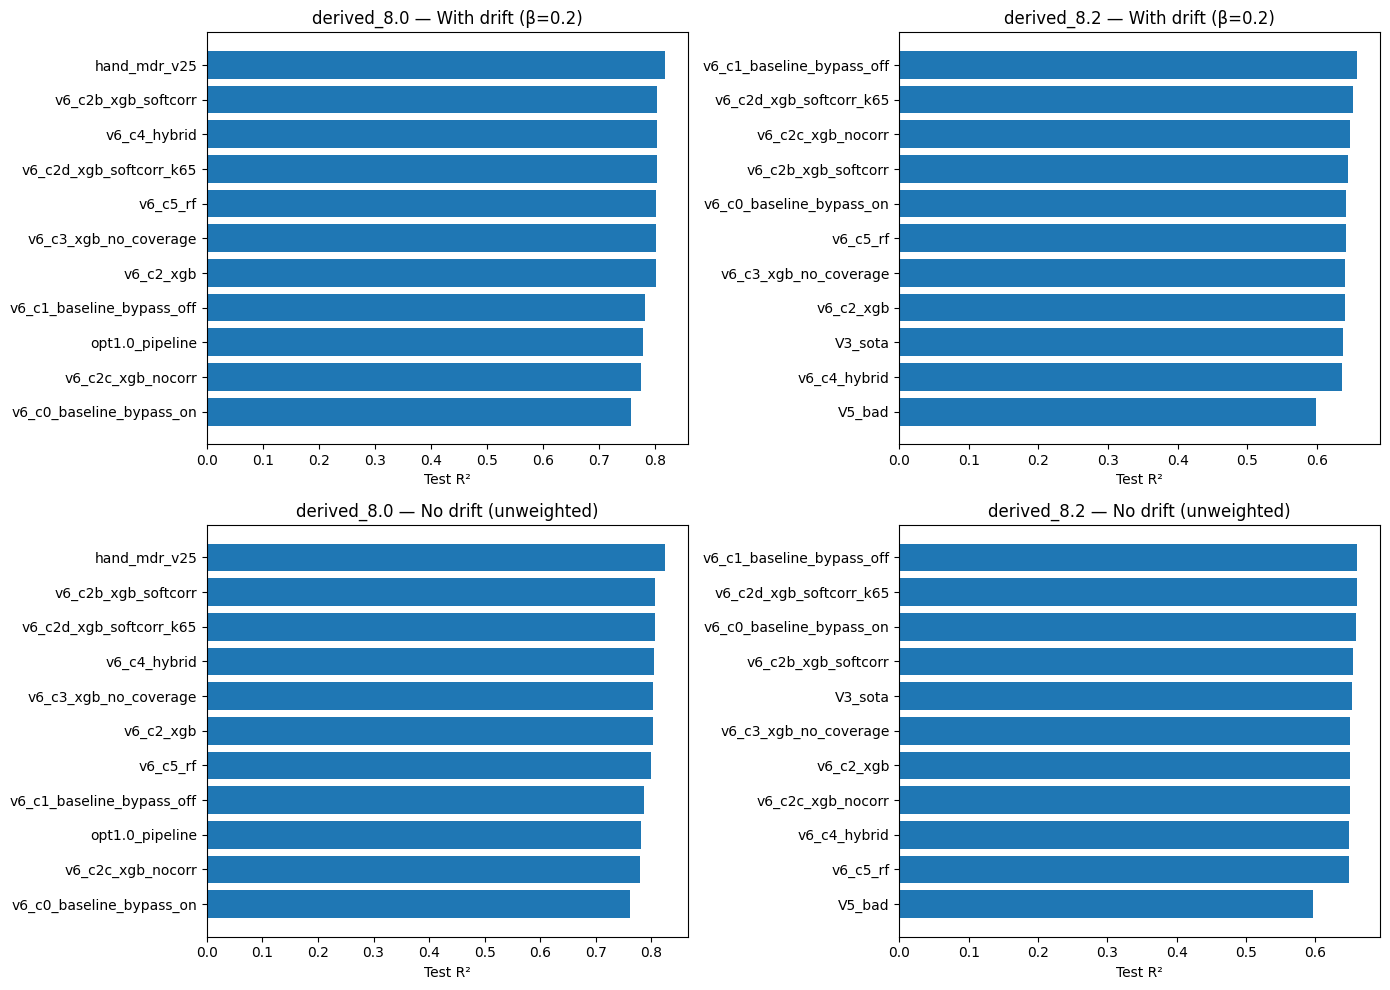

with_drift: FAIL / INCOMPLETE
no_drift: FAIL / INCOMPLETE


In [4]:
def best_v6(df, dataset):
    sub = df[(df.dataset == dataset) & (df.feature_set.str.startswith("v6_"))]
    if sub.empty:
        return None
    return sub.loc[sub["R2"].idxmax()]


def gate_report(summary_slice: pd.DataFrame) -> dict:
    """Gates within a single protocol slice (already filtered by weighted)."""
    report = {}
    s80 = summary_slice[summary_slice.dataset == "derived_8.0"]
    hand = s80[s80.feature_set == "hand_mdr_v25"]
    v6 = best_v6(summary_slice, "derived_8.0")
    if len(hand) and v6 is not None:
        hand_r2 = float(hand.iloc[0]["R2"])
        v6_r2 = float(v6["R2"])
        report["8.0"] = {
            "hand_r2": hand_r2,
            "best_v6": v6["feature_set"],
            "best_v6_r2": v6_r2,
            "delta": v6_r2 - hand_r2,
            "pass": bool(v6_r2 >= hand_r2 - 0.01),
        }

    s82 = summary_slice[summary_slice.dataset == "derived_8.2"]
    v3 = s82[s82.feature_set == "V3_sota"]
    v6b = best_v6(summary_slice, "derived_8.2")
    if len(v3) and v6b is not None:
        v3_r2 = float(v3.iloc[0]["R2"])
        v6_r2 = float(v6b["R2"])
        report["8.2"] = {
            "v3_r2": v3_r2,
            "best_v6": v6b["feature_set"],
            "best_v6_r2": v6_r2,
            "delta": v6_r2 - v3_r2,
            "pass": bool(v6_r2 >= v3_r2 - 0.01),
        }
    return report


if len(summary):
    gates = {
        "with_drift": gate_report(summary[summary.weighted]),
        "no_drift": gate_report(summary[~summary.weighted]),
    }
    print(json.dumps(gates, indent=2))
    (OUT_DIR / "success_gates.json").write_text(json.dumps(gates, indent=2))

    # 2x2: rows = protocol, cols = dataset
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
    protocols = [(True, "With drift (β=0.2)"), (False, "No drift (unweighted)")]
    for row_i, (weighted, prot_title) in enumerate(protocols):
        for col_i, ds in enumerate(["derived_8.0", "derived_8.2"]):
            ax = axes[row_i, col_i]
            sub = summary[(summary.dataset == ds) & (summary.weighted == weighted)].sort_values("R2")
            if sub.empty:
                ax.set_title(f"{ds}: no data")
                continue
            ax.barh(sub["feature_set"], sub["R2"])
            ax.set_title(f"{ds} — {prot_title}")
            ax.set_xlabel("Test R²")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "r2_comparison.png", dpi=140)
    fig.savefig(OUT_DIR / "r2_comparison_weighted.png", dpi=140)  # alias kept for back-compat
    # also save per-protocol copies
    for weighted, tag in [(True, "weighted"), (False, "unweighted")]:
        fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
        for ax, ds in zip(axes2, ["derived_8.0", "derived_8.2"]):
            sub = summary[(summary.dataset == ds) & (summary.weighted == weighted)].sort_values("R2")
            if sub.empty:
                continue
            ax.barh(sub["feature_set"], sub["R2"])
            ax.set_title(f"{ds} test R² ({tag})")
            ax.set_xlabel("R²")
        plt.tight_layout()
        fig2.savefig(OUT_DIR / f"r2_comparison_{tag}.png", dpi=140)
        plt.close(fig2)
    plt.show()

    for prot, g in gates.items():
        ok = all(v.get("pass") for v in g.values()) if g else False
        print(f"{prot}: {'PASS' if ok else 'FAIL / INCOMPLETE'}")
else:
    print("No evaluation rows — run pipeline artifacts first.")


## Notes

- **With drift:** exponential year weights β=0.2. **No drift:** uniform sample weights.
- Models train on train+val concatenated (no early stopping), matching the optimization-1.0 protocol.
- Both protocols use the same 1.3-lite XGBoost hyperparameters.
- Promote the winning V6 variant to `dataset_metadata.py` only after gates pass under the intended deployment protocol.
